## Import necessary libraries

In [1]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from torchvision.transforms import transforms
from torchsummary import summary
from torch.optim import Adam
from PIL import Image
from torch import nn

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import kagglehub
import torch
import os

## Set device

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


## Download data

In [3]:
path = kagglehub.dataset_download("tushar5harma/plant-village-dataset-updated")

print("Path to dataset files:", path)

100%|██████████| 1.00G/1.00G [00:28<00:00, 38.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tushar5harma/plant-village-dataset-updated/versions/2


## Define helper functions and classes

In [4]:
species_list = []

for species in os.listdir(path):
    species_list.append(species)

species_list

['Corn (Maize)',
 'Bell Pepper',
 'Apple',
 'Peach',
 'Tomato',
 'Potato',
 'Strawberry',
 'Cherry',
 'Grape']

In [5]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

def create_dataframes(species):
    if species not in species_list:
        raise ValueError("Species not found in dataset")

    # Create training dataframe
    image_paths = []
    labels = []

    for label in os.listdir(os.path.join(path, species, "Train")):
        for image_path in os.listdir(os.path.join(path, species, "Train", label)):
            image_path = os.path.join(path, species, "Train", label, image_path)

            if not os.path.isfile(image_path):
                continue

            image_paths.append(image_path)
            labels.append(label)

    training_df = pd.DataFrame(zip(image_paths, labels), columns=["image_path", "label"])

    # Create validation dataframe
    image_paths = []
    labels = []

    for label in os.listdir(os.path.join(path, species, "Val")):
        for image_path in os.listdir(os.path.join(path, species, "Val", label)):
            image_path = os.path.join(path, species, "Val", label, image_path)

            if not os.path.isfile(image_path):
                continue

            image_paths.append(image_path)
            labels.append(label)

    validation_df = pd.DataFrame(zip(image_paths, labels), columns=["image_path", "label"])

    # Create test dataframe
    image_paths = []
    labels = []

    for label in os.listdir(os.path.join(path, species, "Test")):
        for image_path in os.listdir(os.path.join(path, species, "Test", label)):
            image_path = os.path.join(path, species, "Test", label, image_path)

            if not os.path.isfile(image_path):
                continue

            image_paths.append(image_path)
            labels.append(label)

    test_df = pd.DataFrame(zip(image_paths, labels), columns=["image_path", "label"])

    return training_df, validation_df, test_df

def show_sample_data(df):
    n_rows = 3
    n_cols = 3

    f, axarr = plt.subplots(n_rows, n_cols)

    for row in range(n_rows):
        for col in range(n_cols):
            image = Image.open(df.sample(n=1)["image_path"].iloc[0]).convert("RGB")
            axarr[row, col].imshow(image)
            axarr[row, col].axis("off")

    plt.show()

class CustomImageDataset(Dataset):
    def __init__(self, img_paths, labels, label_encoder, transform=None):
        self.img_paths = img_paths
        self.transform = transform
        self.labels = torch.tensor(label_encoder.transform(labels)).to(device)

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths.iloc[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image).to(device)

        return image, label

class PredictorConv(nn.Module):
    def __init__(self, labels_count):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pooling = nn.MaxPool2d(2, 2)

        self.relu = nn.ReLU()

        self.flatten = nn.Flatten()
        self.linear = nn.Linear(128 * 16 * 16, 128)

        self.output = nn.Linear(128, labels_count)

    def forward(self, x):
        x = self.conv1(x)    # (32, 128, 128)
        x = self.pooling(x)  # (32, 64, 64)
        x = self.relu(x)

        x = self.conv2(x)    # (64, 64, 64)
        x = self.pooling(x)  # (64, 32, 32)
        x = self.relu(x)

        x = self.conv3(x)    # (128, 32, 32)
        x = self.pooling(x)  # (128, 16, 16)
        x = self.relu(x)

        x = self.flatten(x)
        x = self.linear(x)
        x = self.output(x)

        return x

def train_model(model, criterion, optimizer, training_dataloader, validation_dataloader, epochs):
    # Model training
    total_loss_training_plot = []
    total_loss_validation_plot = []

    total_acc_training_plot = []
    total_acc_validation_plot = []

    best_diff = np.inf

    for epoch in range(epochs):
        model.train()

        total_loss_train = 0
        accuracy_train = 0
        correct_train = 0
        total_train = 0

        total_loss_val = 0
        accuracy_val = 0
        correct_val = 0
        total_val = 0

        for inputs, labels in training_dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)

            # Loss
            loss = criterion(outputs, labels)

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Stats
            total_loss_train += loss.item()
            correct_train += (torch.argmax(outputs, axis=1) == labels).sum().item()
            total_train += labels.size(0)

        model.eval()
        with torch.no_grad():
            for inputs, labels in validation_dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Forward pass
                outputs = model(inputs)

                # Loss
                loss = criterion(outputs, labels)

                # Stats
                total_loss_val += loss.item()
                correct_val += (torch.argmax(outputs, axis=1) == labels).sum().item()
                total_val += labels.size(0)

        avg_loss_train = total_loss_train / len(training_dataloader)
        accuracy_train = correct_train / total_train

        avg_loss_val = total_loss_val / len(validation_dataloader)
        accuracy_val = correct_val / total_val

        total_loss_training_plot.append(avg_loss_train)
        total_loss_validation_plot.append(avg_loss_val)

        total_acc_training_plot.append(accuracy_train)
        total_acc_validation_plot.append(accuracy_val)

        print(f"""
        Epoch {epoch+1}
          Training loss: {total_loss_training_plot[-1]:.3f}     Training accuracy: {total_acc_training_plot[-1]:.3f}
        Validation Loss: {total_loss_validation_plot[-1]:.3f}   Validation accuracy: {total_acc_validation_plot[-1]:.3f}
        """)

        if total_acc_training_plot[-1] > 0.8 and total_acc_validation_plot[-1] > 0.8:
            diff = np.abs(total_acc_training_plot[-1] - total_acc_validation_plot[-1])

            if diff < best_diff:
                best_diff = diff
            else:
                print("Early stopping")
                break

    # Training progress plotting
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

    ax[0].plot(total_loss_training_plot, label="Training loss")
    ax[0].plot(total_loss_validation_plot, label="Validation loss")
    ax[0].set_title("Training and Validation loss over epoch")
    ax[0].set_xlabel("Epochs")
    ax[0].set_ylabel("Loss")
    ax[0].legend()

    ax[1].plot(total_acc_training_plot, label="Training accuracy")
    ax[1].plot(total_acc_validation_plot, label="Validation accuracy")
    ax[1].set_title("Training and Validation accuracy over epoch")
    ax[1].set_xlabel("Epochs")
    ax[1].set_ylabel("Accuracy")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

def evaluate_model(model, test_dataloader):
    total_loss_test = 0
    accuracy_test = 0
    correct_test = 0
    total_test = 0

    model.eval()
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)

            # Loss
            loss = criterion(outputs, labels)

            # Stats
            total_loss_test += loss.item()
            correct_test += (torch.argmax(outputs, axis=1) == labels).sum().item()
            total_test += labels.size(0)

    avg_loss_test = total_loss_test / len(test_dataloader)
    accuracy_test = correct_test / total_test

    print(f"""Performance on test set
    Average loss: {avg_loss_test:.3f}
        Accuracy: {accuracy_test:.3f}
    """)

def predict_image(image_path, model, label_encoder, transform):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).to(device)

    output = model(image.unsqueeze(0))

    output = torch.argmax(output, axis=1).item()

    return label_encoder.inverse_transform([output])[0]

def save_model(model, label_encoder, classes_count, model_name):
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "classes": label_encoder.classes_,
        "classes_count": classes_count,
    }

    torch.save(checkpoint, model_name)

## Apple model

In [6]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 100

species = "Apple"
model_checkpoint_name = "apple_leaf_disease_predictor.pth"
test_file_path = "/content/apple_scab.jpg"

In [7]:
training_df, validation_df, test_df = create_dataframes(species)

training_df["label"].value_counts()

,count
label,
Apple Scab,2016
Healthy,2008
Black Rot,1987
Cedar Apple Rust,1760


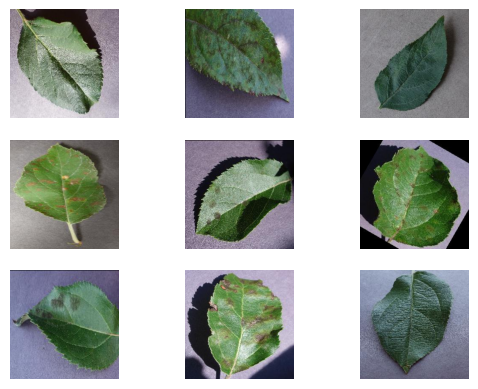

In [8]:
show_sample_data(training_df)

In [9]:
label_encoder = LabelEncoder()
label_encoder.fit(training_df["label"])

LabelEncoder()

In [10]:
training_dataset = CustomImageDataset(training_df["image_path"], training_df["label"], label_encoder, transform)
validation_dataset = CustomImageDataset(validation_df["image_path"], validation_df["label"], label_encoder, transform)
test_dataset = CustomImageDataset(test_df["image_path"], test_df["label"], label_encoder, transform)

In [11]:
training_dataloader = DataLoader(training_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_dataloader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [12]:
classes_count = len(training_df["label"].unique())
model = PredictorConv(classes_count).to(device)
summary(model, (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 4]             516
Total params: 4,288,196
Trainable params: 4,288,196
Non-trainable params: 0
---------------------------

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)


        Epoch 1
          Training loss: 0.587     Training accuracy: 0.771
        Validation Loss: 0.345   Validation accuracy: 0.871
        

        Epoch 2
          Training loss: 0.270     Training accuracy: 0.906
        Validation Loss: 0.197   Validation accuracy: 0.929
        

        Epoch 3
          Training loss: 0.169     Training accuracy: 0.942
        Validation Loss: 0.277   Validation accuracy: 0.899
        
Early stopping


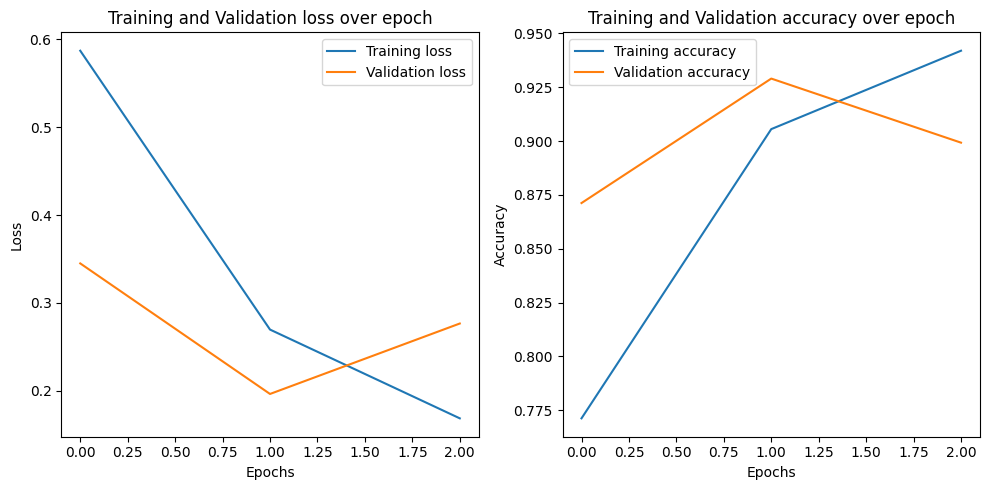

In [14]:
train_model(model, criterion, optimizer, training_dataloader, validation_dataloader, EPOCHS)

In [15]:
evaluate_model(model, test_dataloader)

Performance on test set
    Average loss: 0.314
        Accuracy: 0.898
    


In [16]:
predict_image(test_file_path, model, label_encoder, transform)

'Apple Scab'

In [17]:
save_model(model, label_encoder, classes_count, model_checkpoint_name)

## Bell pepper model

In [18]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 100

species = "Bell Pepper"
model_checkpoint_name = "bell_pepper_leaf_disease_predictor.pth"
test_file_path = "/content/bell_pepper_bacterial_spot.jpg"

In [19]:
training_df, validation_df, test_df = create_dataframes(species)

training_df["label"].value_counts()

,count
label,
Healthy,1988
Bacterial Spot,1913


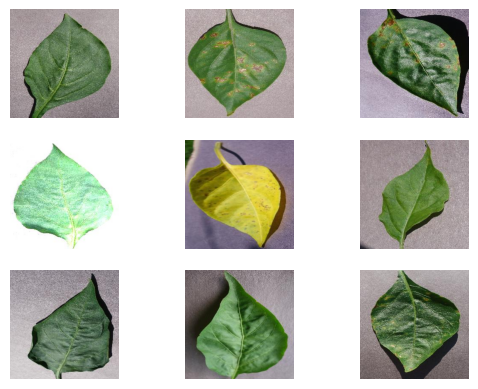

In [20]:
show_sample_data(training_df)

In [21]:
label_encoder = LabelEncoder()
label_encoder.fit(training_df["label"])

LabelEncoder()

In [22]:
training_dataset = CustomImageDataset(training_df["image_path"], training_df["label"], label_encoder, transform)
validation_dataset = CustomImageDataset(validation_df["image_path"], validation_df["label"], label_encoder, transform)
test_dataset = CustomImageDataset(test_df["image_path"], test_df["label"], label_encoder, transform)

In [23]:
training_dataloader = DataLoader(training_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_dataloader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [24]:
classes_count = len(training_df["label"].unique())
model = PredictorConv(classes_count).to(device)
summary(model, (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 2]             258
Total params: 4,287,938
Trainable params: 4,287,938
Non-trainable params: 0
---------------------------

In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)


        Epoch 1
          Training loss: 0.319     Training accuracy: 0.855
        Validation Loss: 0.205   Validation accuracy: 0.901
        

        Epoch 2
          Training loss: 0.205     Training accuracy: 0.913
        Validation Loss: 0.150   Validation accuracy: 0.942
        

        Epoch 3
          Training loss: 0.123     Training accuracy: 0.952
        Validation Loss: 0.145   Validation accuracy: 0.935
        

        Epoch 4
          Training loss: 0.075     Training accuracy: 0.975
        Validation Loss: 0.072   Validation accuracy: 0.979
        

        Epoch 5
          Training loss: 0.069     Training accuracy: 0.977
        Validation Loss: 0.058   Validation accuracy: 0.981
        

        Epoch 6
          Training loss: 0.044     Training accuracy: 0.986
        Validation Loss: 0.077   Validation accuracy: 0.971
        
Early stopping


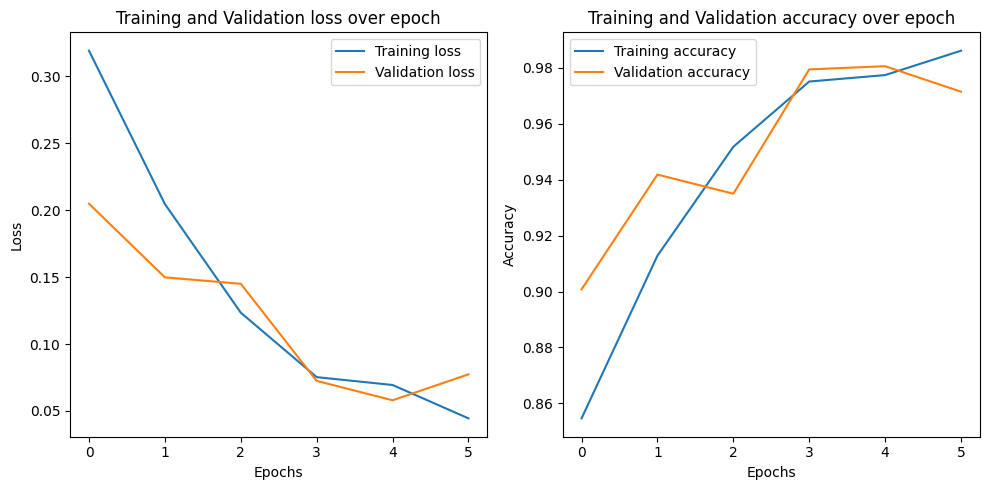

In [26]:
train_model(model, criterion, optimizer, training_dataloader, validation_dataloader, EPOCHS)

In [27]:
evaluate_model(model, test_dataloader)

Performance on test set
    Average loss: 0.053
        Accuracy: 0.980
    


In [28]:
predict_image(test_file_path, model, label_encoder, transform)

'Bacterial Spot'

In [29]:
save_model(model, label_encoder, classes_count, model_checkpoint_name)

## Cherry model

In [30]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 100

species = "Cherry"
model_checkpoint_name = "cherry_leaf_disease_predictor.pth"
test_file_path = "/content/cherry_powdery_mildew.jpg"

In [31]:
training_df, validation_df, test_df = create_dataframes(species)

training_df["label"].value_counts()

,count
label,
Healthy,1826
Powdery Mildew,1683


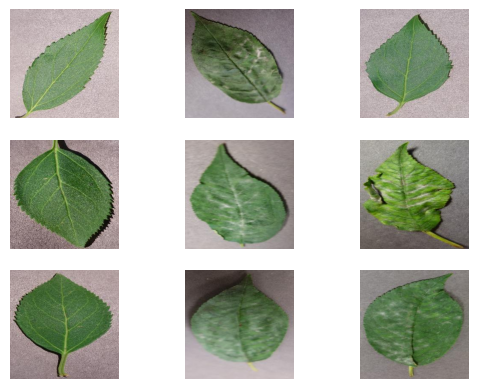

In [32]:
show_sample_data(training_df)

In [33]:
label_encoder = LabelEncoder()
label_encoder.fit(training_df["label"])

LabelEncoder()

In [34]:
training_dataset = CustomImageDataset(training_df["image_path"], training_df["label"], label_encoder, transform)
validation_dataset = CustomImageDataset(validation_df["image_path"], validation_df["label"], label_encoder, transform)
test_dataset = CustomImageDataset(test_df["image_path"], test_df["label"], label_encoder, transform)

In [35]:
training_dataloader = DataLoader(training_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_dataloader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [36]:
classes_count = len(training_df["label"].unique())
model = PredictorConv(classes_count).to(device)
summary(model, (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 2]             258
Total params: 4,287,938
Trainable params: 4,287,938
Non-trainable params: 0
---------------------------

In [37]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)


        Epoch 1
          Training loss: 0.191     Training accuracy: 0.926
        Validation Loss: 0.054   Validation accuracy: 0.985
        

        Epoch 2
          Training loss: 0.042     Training accuracy: 0.987
        Validation Loss: 0.022   Validation accuracy: 0.995
        

        Epoch 3
          Training loss: 0.018     Training accuracy: 0.995
        Validation Loss: 0.011   Validation accuracy: 0.996
        

        Epoch 4
          Training loss: 0.013     Training accuracy: 0.996
        Validation Loss: 0.011   Validation accuracy: 0.997
        
Early stopping


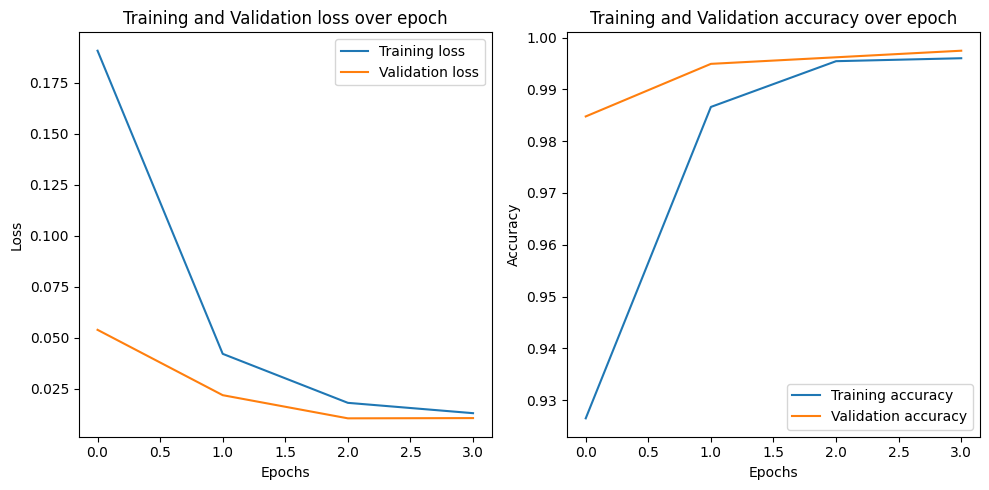

In [38]:
train_model(model, criterion, optimizer, training_dataloader, validation_dataloader, EPOCHS)

In [39]:
evaluate_model(model, test_dataloader)

Performance on test set
    Average loss: 0.002
        Accuracy: 1.000
    


In [40]:
predict_image(test_file_path, model, label_encoder, transform)

'Powdery Mildew'

In [41]:
save_model(model, label_encoder, classes_count, model_checkpoint_name)

## Corn model

In [42]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 100

species = "Corn (Maize)"
model_checkpoint_name = "corn_leaf_disease_predictor.pth"
test_file_path = "/content/corn_common_rust.jpg"

In [43]:
training_df, validation_df, test_df = create_dataframes(species)

training_df["label"].value_counts()

,count
label,
Northern Leaf Blight,1908
Common Rust,1907
Healthy,1859
Cercospora Leaf Spot,1642


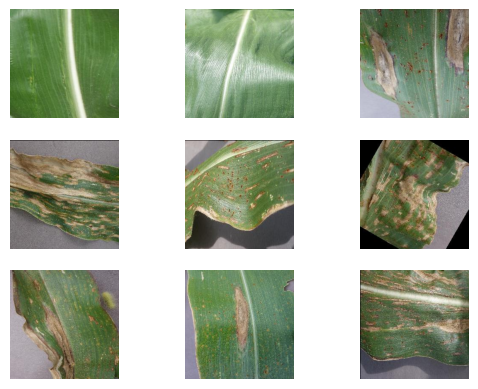

In [44]:
show_sample_data(training_df)

In [45]:
label_encoder = LabelEncoder()
label_encoder.fit(training_df["label"])

LabelEncoder()

In [46]:
training_dataset = CustomImageDataset(training_df["image_path"], training_df["label"], label_encoder, transform)
validation_dataset = CustomImageDataset(validation_df["image_path"], validation_df["label"], label_encoder, transform)
test_dataset = CustomImageDataset(test_df["image_path"], test_df["label"], label_encoder, transform)

In [47]:
training_dataloader = DataLoader(training_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_dataloader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [48]:
classes_count = len(training_df["label"].unique())
model = PredictorConv(classes_count).to(device)
summary(model, (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 4]             516
Total params: 4,288,196
Trainable params: 4,288,196
Non-trainable params: 0
---------------------------

In [49]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)


        Epoch 1
          Training loss: 0.365     Training accuracy: 0.852
        Validation Loss: 0.214   Validation accuracy: 0.914
        

        Epoch 2
          Training loss: 0.160     Training accuracy: 0.936
        Validation Loss: 0.137   Validation accuracy: 0.939
        

        Epoch 3
          Training loss: 0.129     Training accuracy: 0.953
        Validation Loss: 0.133   Validation accuracy: 0.945
        
Early stopping


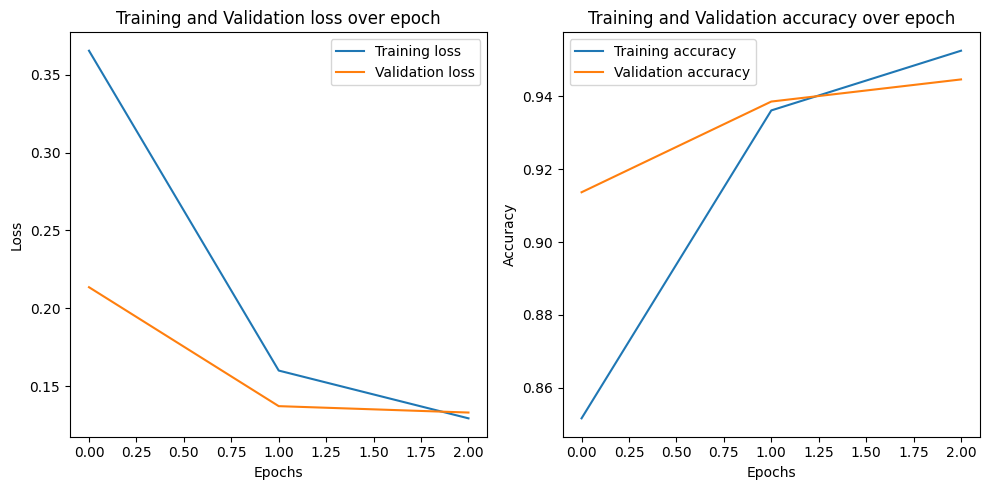

In [50]:
train_model(model, criterion, optimizer, training_dataloader, validation_dataloader, EPOCHS)

In [51]:
evaluate_model(model, test_dataloader)

Performance on test set
    Average loss: 0.263
        Accuracy: 0.918
    


In [52]:
predict_image(test_file_path, model, label_encoder, transform)

'Common Rust '

In [53]:
save_model(model, label_encoder, classes_count, model_checkpoint_name)

## Grape model

In [54]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 100

species = "Grape"
model_checkpoint_name = "grape_leaf_disease_predictor.pth"
test_file_path = "/content/grape_esca.jpg"

In [55]:
training_df, validation_df, test_df = create_dataframes(species)

training_df["label"].value_counts()

,count
label,
Esca (Black Measles),1920
Black Rot,1888
Leaf Blight,1722
Healthy,1692


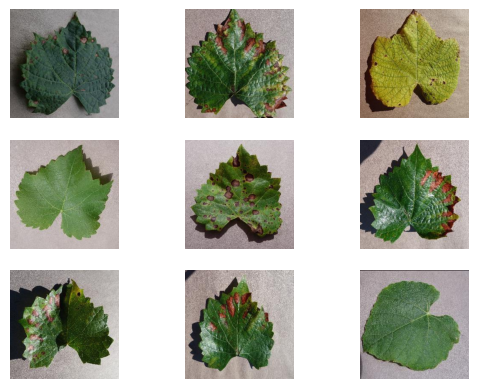

In [56]:
show_sample_data(training_df)

In [57]:
label_encoder = LabelEncoder()
label_encoder.fit(training_df["label"])

LabelEncoder()

In [58]:
training_dataset = CustomImageDataset(training_df["image_path"], training_df["label"], label_encoder, transform)
validation_dataset = CustomImageDataset(validation_df["image_path"], validation_df["label"], label_encoder, transform)
test_dataset = CustomImageDataset(test_df["image_path"], test_df["label"], label_encoder, transform)

In [59]:
training_dataloader = DataLoader(training_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_dataloader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [60]:
classes_count = len(training_df["label"].unique())
model = PredictorConv(classes_count).to(device)
summary(model, (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 4]             516
Total params: 4,288,196
Trainable params: 4,288,196
Non-trainable params: 0
---------------------------

In [61]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)


        Epoch 1
          Training loss: 0.519     Training accuracy: 0.778
        Validation Loss: 0.274   Validation accuracy: 0.893
        

        Epoch 2
          Training loss: 0.240     Training accuracy: 0.904
        Validation Loss: 0.168   Validation accuracy: 0.940
        

        Epoch 3
          Training loss: 0.175     Training accuracy: 0.935
        Validation Loss: 0.153   Validation accuracy: 0.939
        

        Epoch 4
          Training loss: 0.143     Training accuracy: 0.946
        Validation Loss: 0.137   Validation accuracy: 0.947
        

        Epoch 5
          Training loss: 0.123     Training accuracy: 0.954
        Validation Loss: 0.110   Validation accuracy: 0.954
        

        Epoch 6
          Training loss: 0.108     Training accuracy: 0.958
        Validation Loss: 0.137   Validation accuracy: 0.940
        
Early stopping


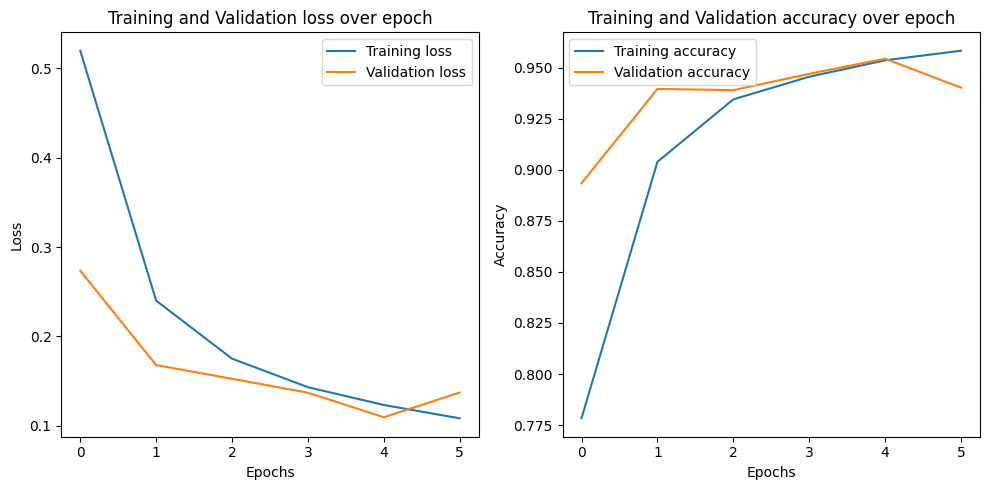

In [62]:
train_model(model, criterion, optimizer, training_dataloader, validation_dataloader, EPOCHS)

In [63]:
evaluate_model(model, test_dataloader)

Performance on test set
    Average loss: 0.186
        Accuracy: 0.934
    


In [64]:
predict_image(test_file_path, model, label_encoder, transform)

'Esca (Black Measles)'

In [65]:
save_model(model, label_encoder, classes_count, model_checkpoint_name)

## Peach model

In [66]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 100

species = "Peach"
model_checkpoint_name = "peach_leaf_disease_predictor.pth"
test_file_path = "/content/peach_bacterial_spot.jpg"

In [67]:
training_df, validation_df, test_df = create_dataframes(species)

training_df["label"].value_counts()

,count
label,
Bacterial Spot,1838
Healthy,1728


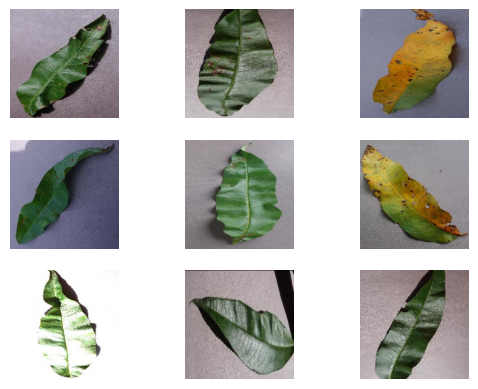

In [68]:
show_sample_data(training_df)

In [69]:
label_encoder = LabelEncoder()
label_encoder.fit(training_df["label"])

LabelEncoder()

In [70]:
training_dataset = CustomImageDataset(training_df["image_path"], training_df["label"], label_encoder, transform)
validation_dataset = CustomImageDataset(validation_df["image_path"], validation_df["label"], label_encoder, transform)
test_dataset = CustomImageDataset(test_df["image_path"], test_df["label"], label_encoder, transform)

In [71]:
training_dataloader = DataLoader(training_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_dataloader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [72]:
classes_count = len(training_df["label"].unique())
model = PredictorConv(classes_count).to(device)
summary(model, (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 2]             258
Total params: 4,287,938
Trainable params: 4,287,938
Non-trainable params: 0
---------------------------

In [73]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)


        Epoch 1
          Training loss: 0.189     Training accuracy: 0.917
        Validation Loss: 0.182   Validation accuracy: 0.918
        

        Epoch 2
          Training loss: 0.061     Training accuracy: 0.977
        Validation Loss: 0.035   Validation accuracy: 0.988
        
Early stopping


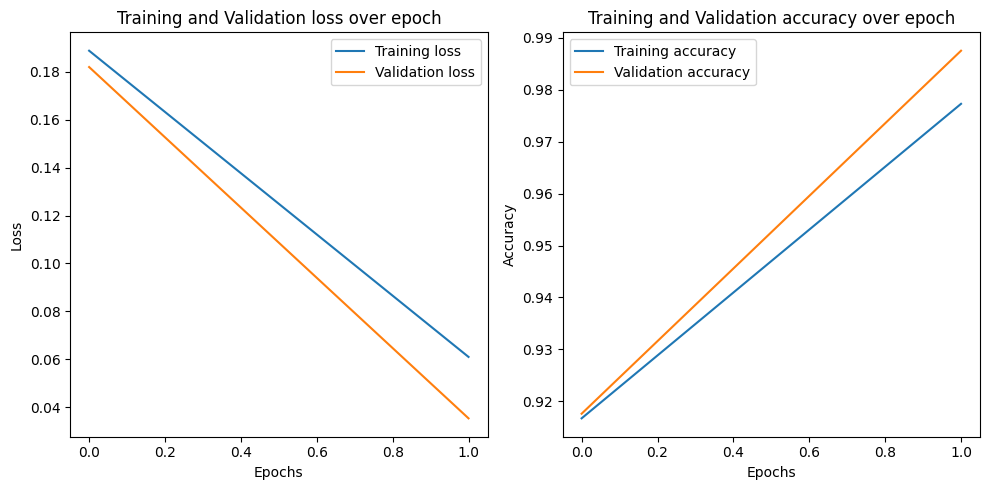

In [74]:
train_model(model, criterion, optimizer, training_dataloader, validation_dataloader, EPOCHS)

In [75]:
evaluate_model(model, test_dataloader)

Performance on test set
    Average loss: 0.012
        Accuracy: 1.000
    


In [76]:
predict_image(test_file_path, model, label_encoder, transform)

'Bacterial Spot'

In [77]:
save_model(model, label_encoder, classes_count, model_checkpoint_name)

## Potato model

In [78]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 100

species = "Potato"
model_checkpoint_name = "potato_leaf_disease_predictor.pth"
test_file_path = "/content/potato_early_blight.jpg"

In [79]:
training_df, validation_df, test_df = create_dataframes(species)

training_df["label"].value_counts()

,count
label,
Early Blight,1939
Late Blight,1939
Healthy,1824


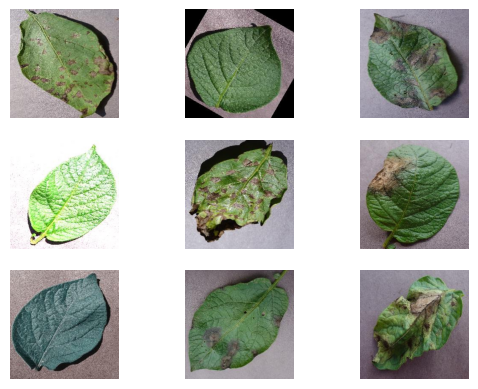

In [80]:
show_sample_data(training_df)

In [81]:
label_encoder = LabelEncoder()
label_encoder.fit(training_df["label"])

LabelEncoder()

In [82]:
training_dataset = CustomImageDataset(training_df["image_path"], training_df["label"], label_encoder, transform)
validation_dataset = CustomImageDataset(validation_df["image_path"], validation_df["label"], label_encoder, transform)
test_dataset = CustomImageDataset(test_df["image_path"], test_df["label"], label_encoder, transform)

In [83]:
training_dataloader = DataLoader(training_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_dataloader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [84]:
classes_count = len(training_df["label"].unique())
model = PredictorConv(classes_count).to(device)
summary(model, (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [85]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)


        Epoch 1
          Training loss: 0.496     Training accuracy: 0.791
        Validation Loss: 0.286   Validation accuracy: 0.894
        

        Epoch 2
          Training loss: 0.242     Training accuracy: 0.911
        Validation Loss: 0.263   Validation accuracy: 0.887
        

        Epoch 3
          Training loss: 0.136     Training accuracy: 0.949
        Validation Loss: 0.112   Validation accuracy: 0.954
        

        Epoch 4
          Training loss: 0.085     Training accuracy: 0.969
        Validation Loss: 0.082   Validation accuracy: 0.970
        

        Epoch 5
          Training loss: 0.065     Training accuracy: 0.976
        Validation Loss: 0.065   Validation accuracy: 0.973
        
Early stopping


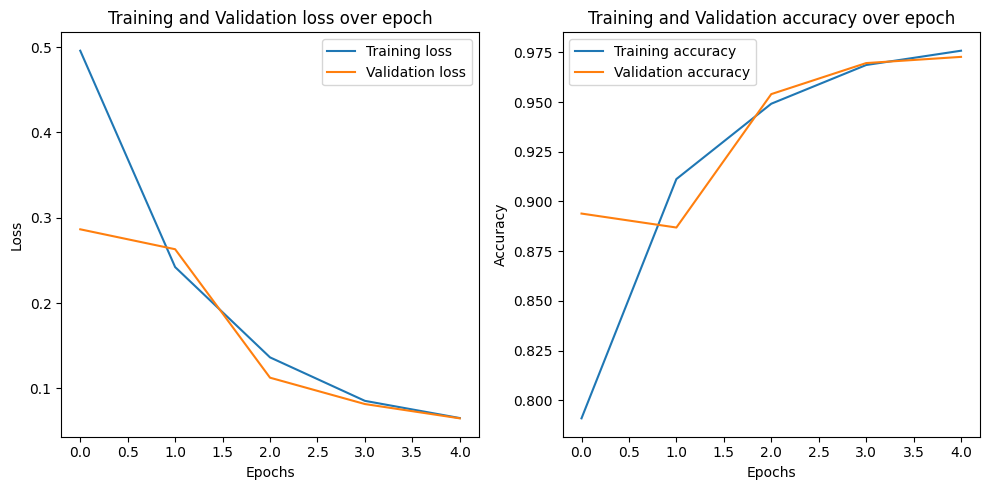

In [86]:
train_model(model, criterion, optimizer, training_dataloader, validation_dataloader, EPOCHS)

In [87]:
evaluate_model(model, test_dataloader)

Performance on test set
    Average loss: 0.051
        Accuracy: 0.972
    


In [88]:
predict_image(test_file_path, model, label_encoder, transform)

'Early Blight'

In [89]:
save_model(model, label_encoder, classes_count, model_checkpoint_name)

## Strawberry model

In [90]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 100

species = "Strawberry"
model_checkpoint_name = "strawberry_leaf_disease_predictor.pth"
test_file_path = "/content/strawberry_leaf_scorch.jpg"

In [91]:
training_df, validation_df, test_df = create_dataframes(species)

training_df["label"].value_counts()

,count
label,
Healthy,1824
Leaf Scorch,1774


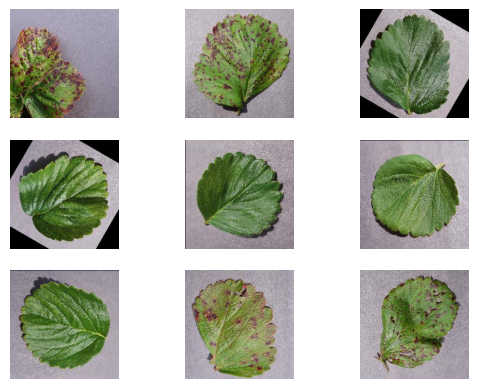

In [92]:
show_sample_data(training_df)

In [93]:
label_encoder = LabelEncoder()
label_encoder.fit(training_df["label"])

LabelEncoder()

In [94]:
training_dataset = CustomImageDataset(training_df["image_path"], training_df["label"], label_encoder, transform)
validation_dataset = CustomImageDataset(validation_df["image_path"], validation_df["label"], label_encoder, transform)
test_dataset = CustomImageDataset(test_df["image_path"], test_df["label"], label_encoder, transform)

In [95]:
training_dataloader = DataLoader(training_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_dataloader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [96]:
classes_count = len(training_df["label"].unique())
model = PredictorConv(classes_count).to(device)
summary(model, (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 2]             258
Total params: 4,287,938
Trainable params: 4,287,938
Non-trainable params: 0
---------------------------

In [97]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)


        Epoch 1
          Training loss: 0.219     Training accuracy: 0.896
        Validation Loss: 0.054   Validation accuracy: 0.977
        

        Epoch 2
          Training loss: 0.038     Training accuracy: 0.986
        Validation Loss: 0.051   Validation accuracy: 0.979
        

        Epoch 3
          Training loss: 0.025     Training accuracy: 0.991
        Validation Loss: 0.019   Validation accuracy: 0.995
        

        Epoch 4
          Training loss: 0.019     Training accuracy: 0.994
        Validation Loss: 0.022   Validation accuracy: 0.989
        
Early stopping


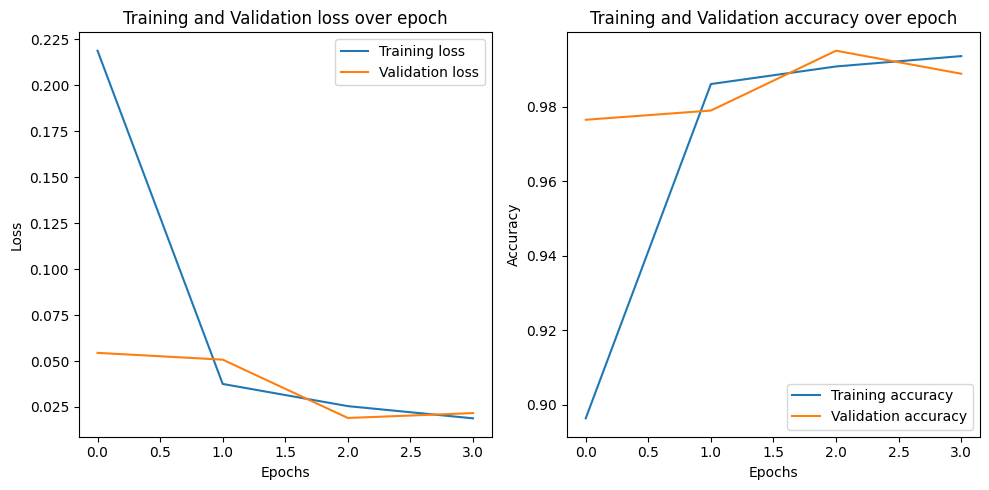

In [98]:
train_model(model, criterion, optimizer, training_dataloader, validation_dataloader, EPOCHS)

In [99]:
evaluate_model(model, test_dataloader)

Performance on test set
    Average loss: 0.009
        Accuracy: 0.989
    


In [100]:
predict_image(test_file_path, model, label_encoder, transform)

'Leaf Scorch'

In [101]:
save_model(model, label_encoder, classes_count, model_checkpoint_name)

## Tomato model

In [102]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 100

species = "Tomato"
model_checkpoint_name = "tomato_leaf_disease_predictor.pth"
test_file_path = "/content/tomato_late_blight.jpg"

In [103]:
training_df, validation_df, test_df = create_dataframes(species)

training_df["label"].value_counts()

,count
label,
Yellow Leaf Curl Virus,1961
Healthy,1926
Early Blight,1920
Late Blight,1851
Septoria Leaf Spot,1745
Bacterial Spot,1702


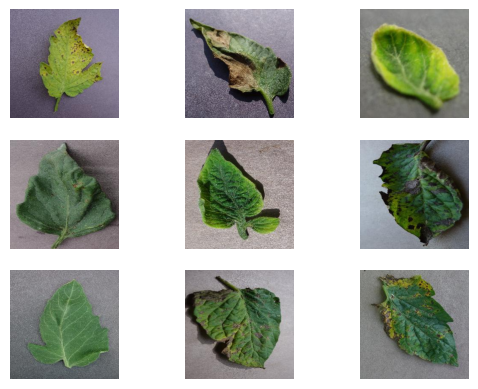

In [104]:
show_sample_data(training_df)

In [105]:
label_encoder = LabelEncoder()
label_encoder.fit(training_df["label"])

LabelEncoder()

In [106]:
training_dataset = CustomImageDataset(training_df["image_path"], training_df["label"], label_encoder, transform)
validation_dataset = CustomImageDataset(validation_df["image_path"], validation_df["label"], label_encoder, transform)
test_dataset = CustomImageDataset(test_df["image_path"], test_df["label"], label_encoder, transform)

In [107]:
training_dataloader = DataLoader(training_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_dataloader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [108]:
classes_count = len(training_df["label"].unique())
model = PredictorConv(classes_count).to(device)
summary(model, (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 6]             774
Total params: 4,288,454
Trainable params: 4,288,454
Non-trainable params: 0
---------------------------

In [109]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)


        Epoch 1
          Training loss: 0.815     Training accuracy: 0.692
        Validation Loss: 0.513   Validation accuracy: 0.812
        

        Epoch 2
          Training loss: 0.429     Training accuracy: 0.844
        Validation Loss: 0.365   Validation accuracy: 0.866
        

        Epoch 3
          Training loss: 0.327     Training accuracy: 0.884
        Validation Loss: 0.312   Validation accuracy: 0.885
        

        Epoch 4
          Training loss: 0.261     Training accuracy: 0.907
        Validation Loss: 0.315   Validation accuracy: 0.882
        
Early stopping


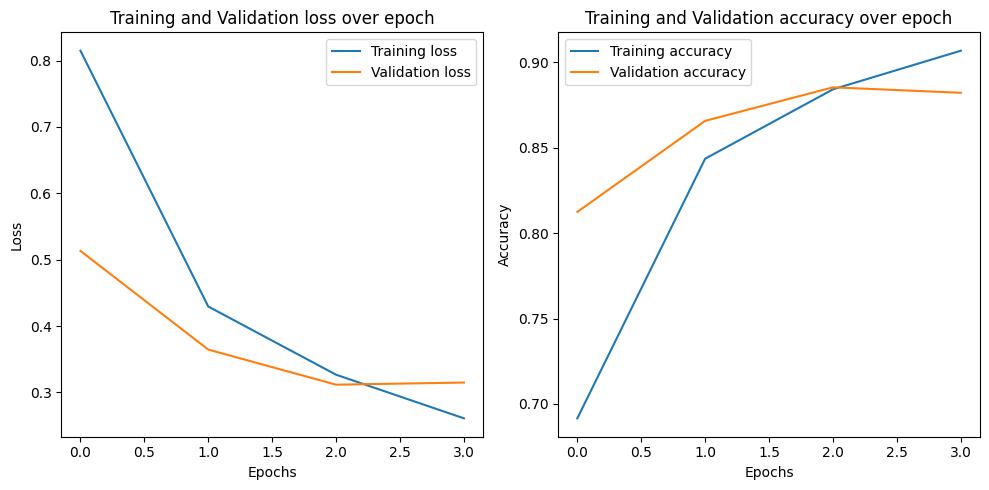

In [110]:
train_model(model, criterion, optimizer, training_dataloader, validation_dataloader, EPOCHS)

In [111]:
evaluate_model(model, test_dataloader)

Performance on test set
    Average loss: 0.350
        Accuracy: 0.875
    


In [112]:
predict_image(test_file_path, model, label_encoder, transform)

'Healthy'

In [113]:
save_model(model, label_encoder, classes_count, model_checkpoint_name)